# Car Price Analysis Project
## Machine Learning Assignment 1

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


# Task 1: Exploratory Data Analysis

In [36]:
# shape of dataset (How many rows and columns does the dataset have?)

df.shape

(72435, 10)

In [37]:
#  Data Types and

df.dtypes

model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

In [38]:
#  Feature Classification (Which features are numerical? Which are categorical? )

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20876\3807493698.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [39]:
#Missing Values (Are there any missing values? How many, and in which columns?)

df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

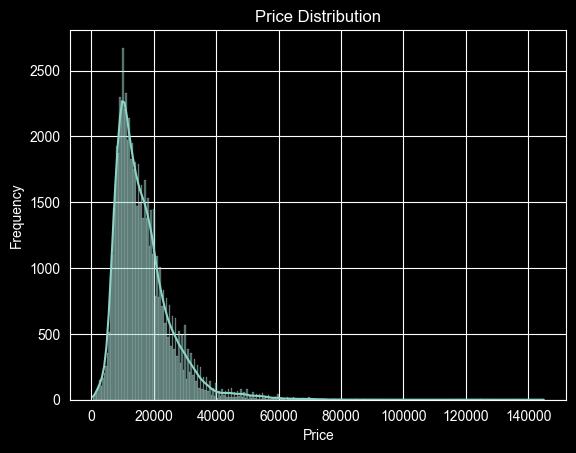

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


In [40]:
#Price Distribution ( What does the distribution of car prices look like? )

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(df['price'].describe())

The distribution is right-skewed, meaning most cars are low-priced with few expensive ones

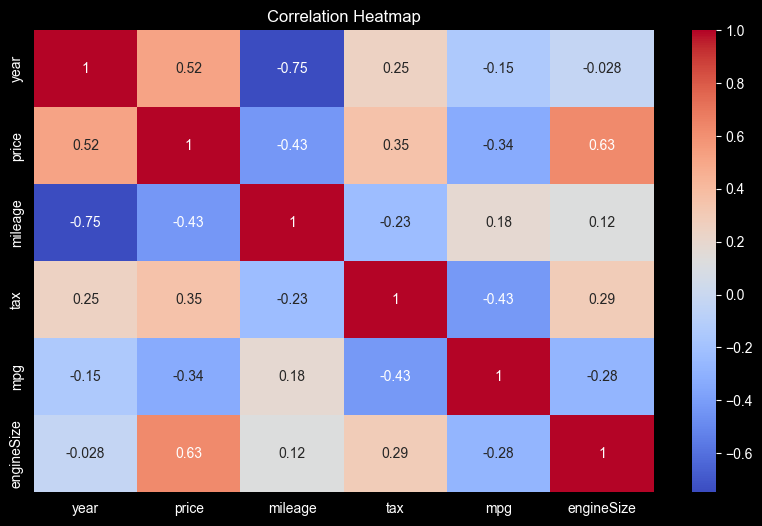

In [41]:
# Correlation Between Features (Which features seem most related to price? )

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [42]:
corr['price'].sort_values(ascending=False)

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64

The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

 ### Relationship Between Price and Important Features

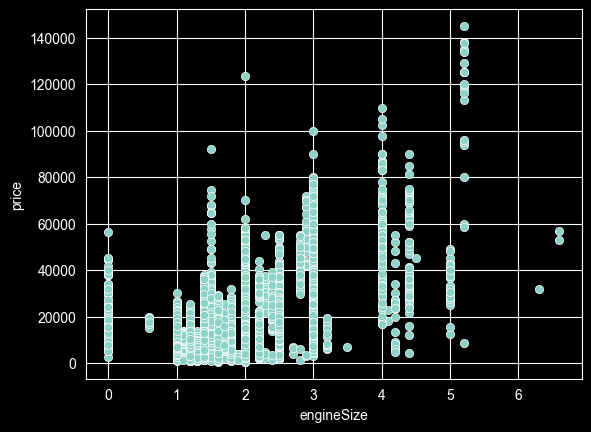

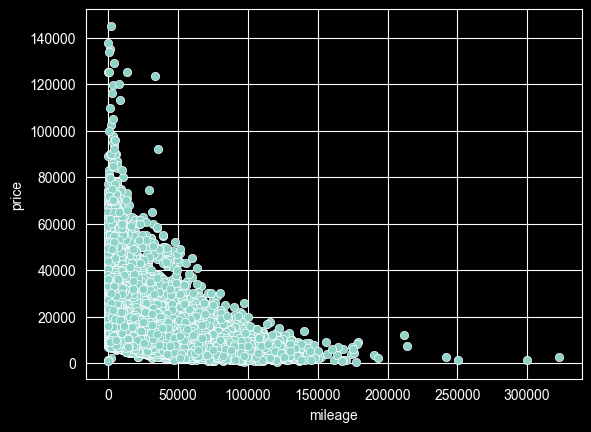

In [43]:
# numerical (most related)
sns.scatterplot(x=df['engineSize'], y=df['price'])
plt.show()

sns.scatterplot(x=df['mileage'], y=df['price'])
plt.show()

In [44]:
#categorical
print(df.groupby('model')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('Make')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('fuelType')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('transmission')['price'].mean().sort_values(ascending=False))

model
R8            97257.080000
X7            69878.187500
8 Series      64424.875000
Q8            59598.133333
California    57565.500000
                  ...     
Getz           1927.500000
Streetka       1924.500000
Amica          1750.000000
Fox            1733.500000
Accent         1295.000000
Name: price, Length: 145, dtype: float64
------------
Make
audi       22894.679872
BMW        22727.820273
vw         16837.325011
skoda      14292.749382
Hyundai    12806.737070
toyota     12504.774279
Ford       12279.505885
Name: price, dtype: float64
------------
fuelType
Hybrid      19067.922073
Diesel      18885.788116
Other       17414.302885
Electric    17374.600000
Petrol      14743.939671
Name: price, dtype: float64
------------
transmission
Semi-Auto    23493.355456
Automatic    21373.580206
Other        14571.000000
Manual       12543.124548
Name: price, dtype: float64


Based on the analysis of both categorical features (groupby mean) and numerical features (correlation matrix), we can conclude the following :

engineSize (strong positive correlation: 0.63)

year (moderate positive correlation: 0.52)

mileage (moderate negative correlation: -0.43)

model (very strong variation in average price across different car models)

transmission (large differences in average price across categories)

Make (strong variation in average price between brands)


 Overall, engineSize,model, transmission, and Make show the strongest relationship with price, followed by year and mileage.

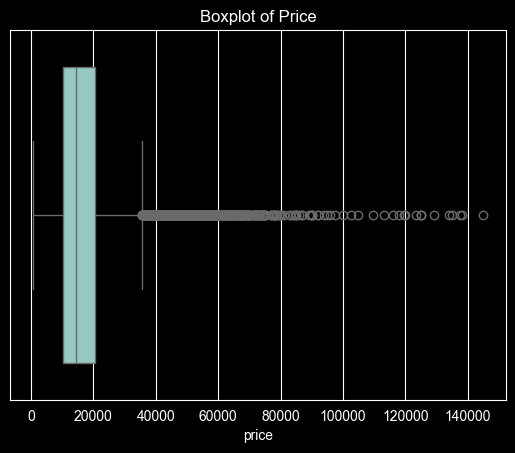

In [45]:
#Outlier Detection

sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

# Task 2 : Data Preprocessing

**step 1 : Handling missing values**
1. First, we drop rows where 'price' is missing because it is the target variable
2. Then, we fill categorical columns (transmission, fuelType , Make) using the mode
3. After that, we fill numerical columns (year, mileage, tax, mpg, engineSize) using the median because it is more robust to outliers
4. Next, we fill missing values in 'model' using group-wise imputation:
    - for each 'Make', we fill with the most frequent 'model' in that group

In [46]:
df_clean = df.copy()

df_clean.dropna(subset=['price'], inplace = True)

categorical_cols = ['transmission', 'fuelType', 'Make']
for col in categorical_cols:
    df_clean[col]= df_clean[col].fillna(df_clean[col].mode()[0])

numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for col in numerical_cols:
    df_clean[col]= df_clean[col].fillna(df_clean[col].median())

df_clean['model'] = df_clean.groupby('Make')['model'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df_clean.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [47]:
df_clean.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


**step 2 : Detect and handle outliers**

In [48]:
df_clean[numerical_cols].describe().round(2)

,year,mileage,tax,mpg,engineSize
count,68814.00,68814.00,68814.00,68814.00,68814.00
mean,2017.07,22907.09,118.37,55.80,1.63
std,2.05,20860.39,62.79,16.69,0.55
min,1996.00,1.00,0.00,0.30,0.00
25%,2016.00,7691.25,125.00,47.90,1.20
50%,2017.00,17526.00,145.00,55.40,1.60
75%,2019.00,31544.00,145.00,62.80,2.00
max,2020.00,323000.00,580.00,470.80,6.60


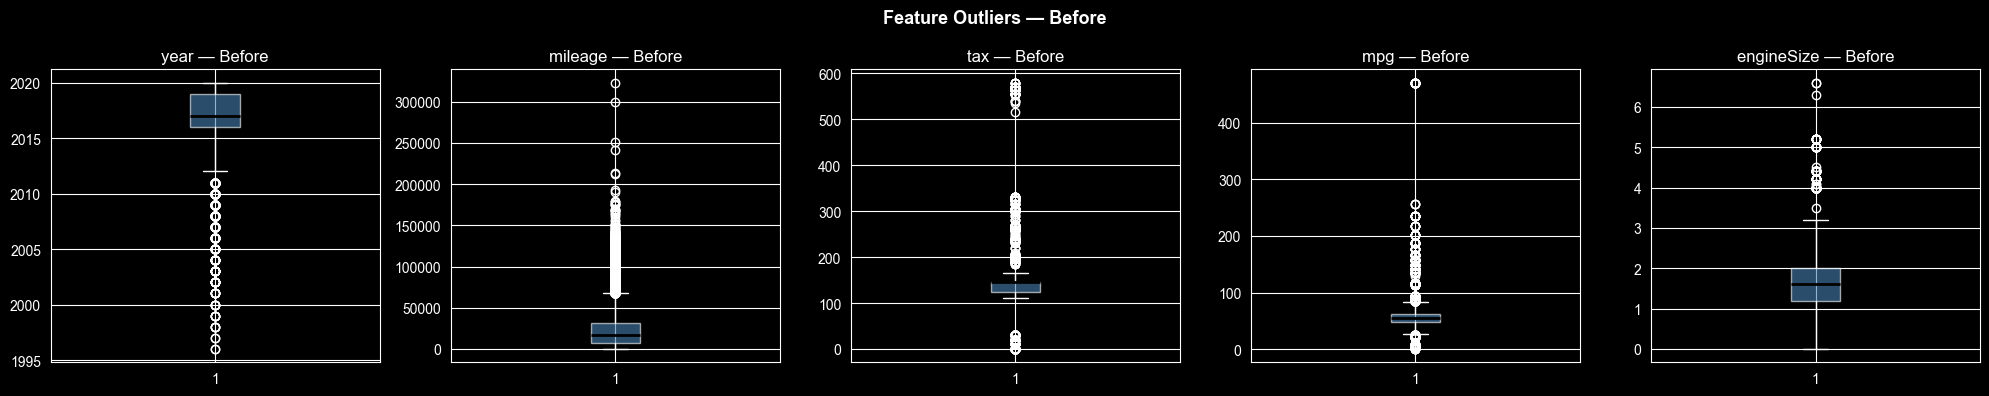

In [49]:
# Before handling
fig_feat, axes_feat = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat[i].boxplot(df_clean[col], patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes_feat[i].set_title(f'{col} — Before')

plt.suptitle('Feature Outliers — Before', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**For features (year, mileage, tax, mpg, engineSize):**
We use the IQR method to detect outliers, then apply Winsorization (clipping) to limit extreme values instead of removing rows, to keep as much data as possible.

In [50]:
# Handling: IQR + Winsorization
for col in numerical_cols:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers bounds [{lower:.2f}, {upper:.2f}]')
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

year: 1146 outliers bounds [2011.50, 2023.50]
mileage: 3040 outliers bounds [-28087.88, 67323.12]
tax: 19801 outliers bounds [95.00, 175.00]
mpg: 1000 outliers bounds [25.55, 85.15]
engineSize: 310 outliers bounds [-0.00, 3.20]


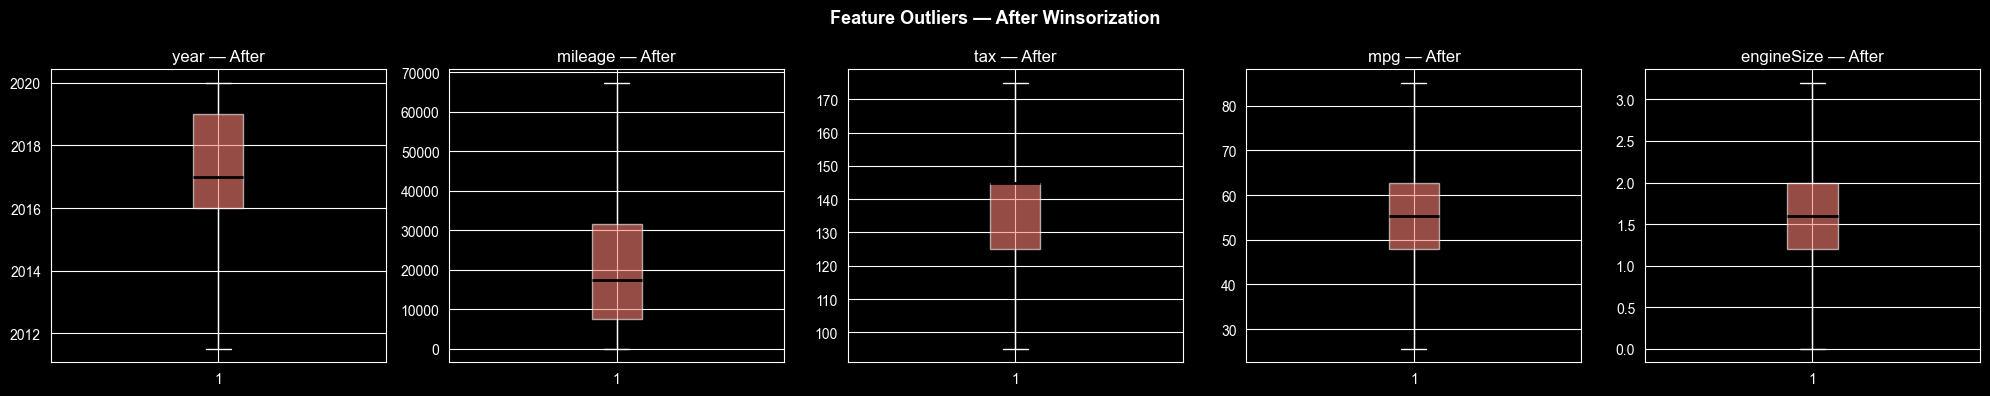

In [51]:
# After
fig_feat2, axes_feat2 = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat2[i].boxplot(df_clean[col], patch_artist=True,
                          boxprops=dict(facecolor='salmon', alpha=0.6),
                          medianprops=dict(color='black', linewidth=2))
    axes_feat2[i].set_title(f'{col} — After')

plt.suptitle('Feature Outliers — After Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

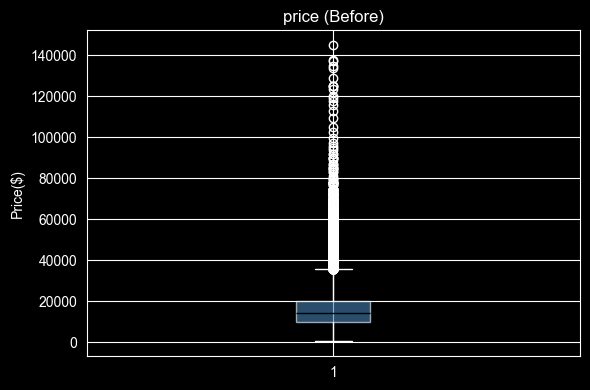

In [52]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (Before)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**For 'price' (target variable):**
We also use IQR to detect outliers, but we remove rows outside the limits, This is because modifying the target may mislead the model.

In [53]:
Q1    = df_clean['price'].quantile(0.25)
Q3    = df_clean['price'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df_clean[(df_clean['price'] < lower) | (df_clean['price'] > upper)]
print(f'Price Outliers : {len(price_outliers)}')

df_clean  = df_clean[(df_clean['price'] >= lower) & (df_clean['price'] <= upper)]

Price Outliers : 2573


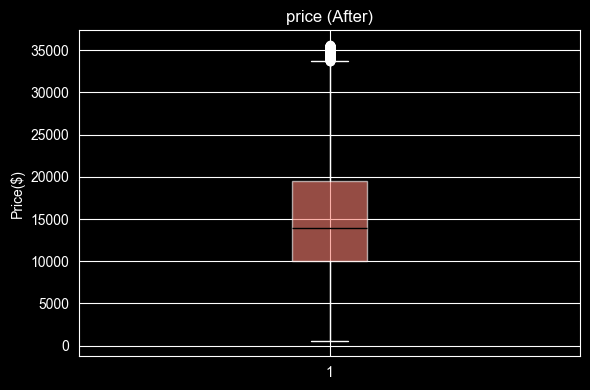

In [54]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='salmon', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (After)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**step 3 : Encoding Categorical columns**

In [55]:
cat_cols_to_encode = ['model', 'transmission', 'fuelType', 'Make']

for col in cat_cols_to_encode:
    print(f"{col}: {df_clean[col].nunique()}")

model: 137
transmission: 4
fuelType: 5
Make: 7


**Label Encoding :**

We use Label Encoding for 'model' because it has many unique values, and One-Hot Encoding would create too many columns.

In [56]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df_clean['model'] = le.fit_transform(df_clean['model'])

**One-Hot Encoding :**

We use One-Hot Encoding for 'transmission', 'fuelType', and 'Make', because they have a small number of categories and no natural order.

In [57]:
ohe_cols = ['transmission', 'fuelType', 'Make']
enc      = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_array         = enc.fit_transform(df_clean[ohe_cols])
ohe_feature_names = enc.get_feature_names_out(ohe_cols)
ohe_df            = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_clean.index)

df_clean = pd.concat([df_clean.drop(columns=ohe_cols), ohe_df], axis=1)

print(f'Shape after encoding: {df_clean.shape}')
df_clean.head()

Shape after encoding: (66241, 23)


,model,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Other,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,7,2017.0,12500.0,15735.0,150.0,55.4,1.4,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,12,2016.0,16500.0,36203.0,95.0,64.2,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,7,2016.0,11000.0,29946.0,95.0,55.4,1.4,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,10,2017.0,16800.0,25952.0,145.0,67.3,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,9,2019.0,17300.0,1998.0,145.0,49.6,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


**step 4 : Scale numerical features**

In [58]:
df_clean[numerical_cols].describe().round(2)

,year,mileage,tax,mpg,engineSize
count,66241.00,66241.00,66241.00,66241.00,66241.00
mean,2017.05,22618.90,133.58,55.88,1.59
std,1.83,18056.37,23.91,10.72,0.48
min,2011.50,1.00,95.00,25.55,0.00
25%,2016.00,8375.00,95.00,48.70,1.20
50%,2017.00,17526.00,145.00,55.40,1.60
75%,2019.00,32185.00,145.00,62.80,2.00
max,2020.00,67323.12,175.00,85.15,3.20


**We apply StandardScaler to numerical features: (year, mileage, tax, mpg, engineSize, model)**, because KNN depends on distance calculations

In [59]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model']
scaler     = StandardScaler()

df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('After scaling:')
print(df_clean[scale_cols].describe().round(2))

After scaling:
           year   mileage       tax       mpg  engineSize     model
count  66241.00  66241.00  66241.00  66241.00    66241.00  66241.00
mean       0.00      0.00     -0.00      0.00       -0.00     -0.00
std        1.00      1.00      1.00      1.00        1.00      1.00
min       -3.03     -1.25     -1.61     -2.83       -3.30     -1.41
25%       -0.57     -0.79     -1.61     -0.67       -0.81     -0.81
50%       -0.03     -0.28      0.48     -0.04        0.02     -0.19
75%        1.06      0.53      0.48      0.65        0.86      0.66
max        1.61      2.48      1.73      2.73        3.35      2.10


## Preprocessing Summary

| Step | Action                                                                                                        | Why                                                                                                       |
|---|---------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| **Missing Values** | Drop rows with missing price; fill Make with Mode first; fill model using group-wise imputation per Make; fill numerical columns with Median; fill categorical columns with Mode | We cannot guess the target; Make is needed for grouping; model depends on Make; Median is safer for numbers; Mode works for categorical data            |
| **Outliers** | Use IQR to detect outliers in feature columns then cap them (Winsorization); drop outlier rows in price column                 | Capping keeps all rows for features; dropping is better for the target so the model learns realistic prices |
| **Encoding** | Label Encoding for model; One-Hot Encoding for transmission, fuelType, Make                                   | model has many unique values; One-Hot would create too many columns; others have no natural order                     |
| **Scaling** | Apply StandardScaler to numerical columns (year, mileage, tax, mpg, engineSize, model); exclude price                                                          | KNN depends on distance; scaling prevents large values from dominating; the target should not be scaled                                      |

## Task 3 : Create Two Target Variables

A. Regression Target (Linear Regression)



In [60]:
# set the price column as my target
y = df['price']
y


0        12500.0
1        16500.0
2        11000.0
3        16800.0
4        17300.0
          ...   
72430     8680.0
72431     7830.0
72432     6830.0
72433    13994.0
72434    15999.0
Name: price, Length: 72435, dtype: float64

B. Classification Target (KNN)

In [61]:
# divide data to three categorical (cheap, Moderate, Expensive)
low_threshold = df_clean['price'].quantile(0.33)
high_threshold = df_clean['price'].quantile(0.66)

conditions = [
    df_clean['price'] <= low_threshold,
    df_clean['price'] >= high_threshold
]

choices = ['cheap', 'expensive']

df_clean['price_cat'] = np.select(conditions, choices, default='moderate')

df_clean['price_cat'].value_counts()

#show original data
df_clean.head()


,model,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Other,...,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw,price_cat
0,-1.224996,-0.029128,12500.0,-0.381248,0.686840,-0.044491,-0.391393,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,moderate
1,-1.096224,-0.574551,16500.0,0.752322,-1.613903,0.776104,0.856723,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,moderate
2,-1.224996,-0.574551,11000.0,0.405793,-1.613903,-0.044491,-0.391393,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,cheap
3,-1.147733,-0.029128,16800.0,0.184595,0.477682,1.065177,0.856723,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,moderate
4,-1.173487,1.061720,17300.0,-1.142038,0.477682,-0.585338,-1.223471,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,moderate


Decide the thresholds (price boundaries) for each category & how many cars in each category:

In [62]:
print("Threshold 1 (Low): ",low_threshold)
print("Threshold 2 (High): ",high_threshold)

# show threshold for each category

print ("The price boundaries: \n" ,"any price lesser than " , low_threshold , " It is considered cheap")
print (" any price greater than " , high_threshold , " It is considered expensive")
print (" any price between " , high_threshold , " and " , low_threshold ," It is considered moderate \n")

# Show how many cars fall into each category after splitting.

print(df_clean['price_cat'].value_counts())

Threshold 1 (Low):  11125.400000000001
Threshold 2 (High):  17480.0
The price boundaries: 
 any price lesser than  11125.400000000001  It is considered cheap
 any price greater than  17480.0  It is considered expensive
 any price between  17480.0  and  11125.400000000001  It is considered moderate 

price_cat
expensive    22533
cheap        21860
moderate     21848
Name: count, dtype: int64


Justify my thresholds — use the data distribution to support your decision

To define the thresholds for the price categories (Cheap, Moderate, and Expensive), I analyzed the price distribution using the percentiles (Quantiles) of the dataset. I chose the 33rd and 66th percentiles as my boundaries for the following reasons:

1.  Data Balance: Using quantiles ensures that each category contains approximately one-third of the total cars. This prevents the KNN model from being biased toward a specific class that might have more data than others (Class Imbalance problem).
2.  Statistical Evidence: Based on the EDA and the describe() function, the 33rd percentile represents the lower-end market, while the 66th percentile marks the transition to premium/high-end cars.
3.  Threshold Values: The calculated boundaries are:
* Cheap: Prices $\le$ 11125
* Moderate: Prices between 11125 and 17480
* Expensive: Prices $>$ 17480

# Task 4: Linear Regression Model
We will train a Linear Regression model to predict the car price.

In [63]:
#splitting data into train and test (80% train, 20% test)
from sklearn.model_selection import train_test_split
X = df_clean.drop(['price','price_cat'], axis=1)
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
#Training model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
#prediction
y_pred = model.predict(X_test)

In [65]:
#Evaluation techniques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2259.78444647388
MSE: 8932159.188724771
RMSE: 2988.6718101398774
R2 Score: 0.8105097782180178


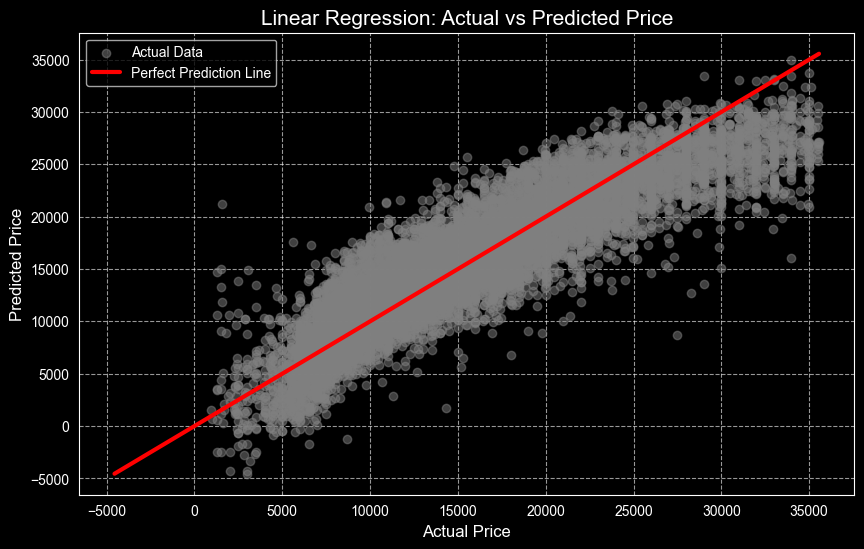

In [66]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot actual vs predicted points
plt.scatter(y_test, y_pred, color='gray', alpha=0.5, label='Actual Data')

# line range (perfect prediction line)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    np.linspace(min_val, max_val, 100),
    np.linspace(min_val, max_val, 100),
    color='red',
    linewidth=3,
    label='Perfect Prediction Line'
)

plt.title('Linear Regression: Actual vs Predicted Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

##  tring to improve model based on correlation
The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

In [67]:
#trying to increase r2 score
df_clean['age'] = 2026 - df_clean['year']
df_clean['engine_per_year'] = df_clean['engineSize'] * df_clean['year']
df_clean['mileage_per_engine'] = df_clean['mileage'] / df_clean['engineSize']
df_clean['age_mileage'] = df_clean['age'] * df_clean['mileage']

X = df_clean.drop(['price', 'price_cat'], axis=1)
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2158.190198406755
MSE: 8310569.255255248
RMSE: 2882.8057956191305
R2: 0.823696423447009


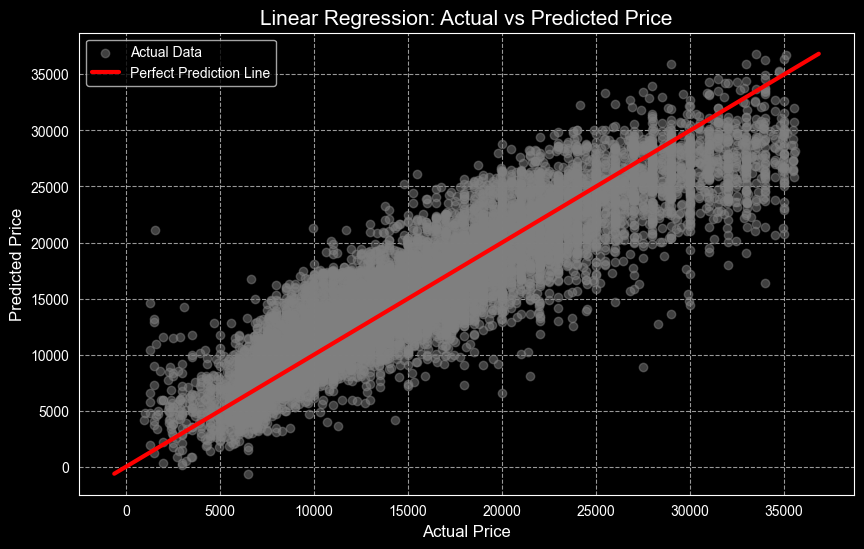

In [68]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted points
plt.scatter(y_test, y_pred, color='gray', alpha=0.5, label='Actual Data')

# line range (perfect prediction line)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    np.linspace(min_val, max_val, 100),
    np.linspace(min_val, max_val, 100),
    color='red',
    linewidth=3,
    label='Perfect Prediction Line'
)

plt.title('Linear Regression: Actual vs Predicted Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Conclusion
R² increased with score from 81% to 82% with using correlated features